<a href="https://colab.research.google.com/github/nanopiero/ML_S5_exam_S2_2026/blob/main/Probleme2_correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problème 2 — Distillation de connaissance



## Contexte

Dans ce problème, on se propose d’étudier le principe de **distillation de connaissance**.

L’objectif général est le suivant : dans de nombreuses applications industrielles, le **coût principal vient de l’inférence** (nombre de paramètres, latence, consommation énergétique).  
On cherche donc souvent à **améliorer les performances d’un modèle de taille donnée**, sans augmenter sa complexité.

La distillation est une technique permettant d’atteindre cet objectif.

Le principe est d’entraîner un modèle simple (**élève**) à reproduire le comportement d’un modèle plus puissant (**professeur**).  
Le professeur est d’abord entraîné normalement sur les données. Ensuite, ses prédictions sont utilisées comme **cible d’apprentissage** pour l’élève.

L’idée clé est que les sorties d’un modèle entraîné contiennent **plus d’information que les étiquettes dures (one-hot)**.  
La distribution de probabilité produite par le professeur peut révéler des relations entre classes qui ne sont pas visibles dans les labels.

Deux approches simples de distillation sont couramment utilisées :

1. **Régression sur les probabilités du professeur**  
   L’élève apprend à reproduire le vecteur de probabilités produit par le professeur.

2. **Entropie croisée entre distributions**  
   On entraîne l’élève à minimiser l’entropie croisée entre sa distribution de sortie et celle du professeur.

Dans cet exercice, on cherchera à déterminer si un modèle simple peut améliorer ses performances **à capacité fixe** en utilisant l’information fournie par un modèle plus puissant.












# Partie 1 — Un jeu de données jouet

On utilisera le dataset :

**Fashion-MNIST**

Ce dataset contient :

- 60 000 images d’entraînement
- 10 000 images de test
- images **28×28 en niveaux de gris**
- 10 classes d’objets vestimentaires

### Travail demandé

1. Télécharger le dataset.
2. Afficher :
   - la taille du jeu d’entraînement et du jeu de test
   - la liste des classes.
3. Visualiser plusieurs images du dataset avec leur label.

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.64MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 178kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.4MB/s]


Taille train set : 60000
Taille test set : 10000
Classes : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


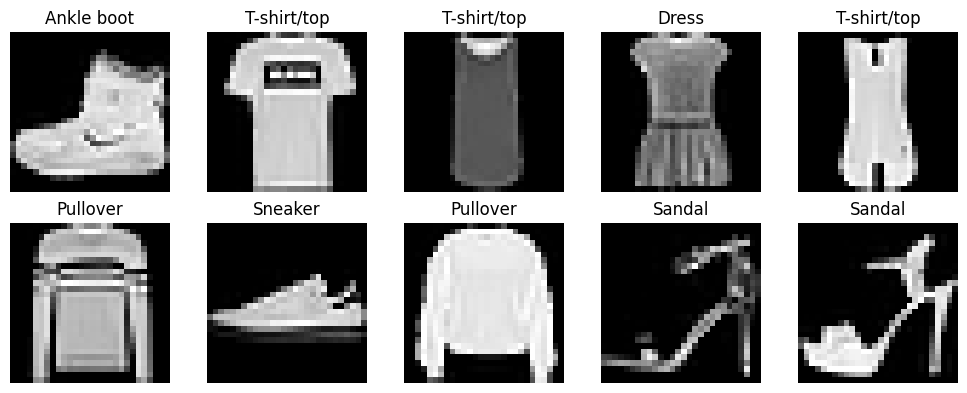

In [1]:
# Partie 1 : téléchargement et exploration de Fashion-MNIST

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Chargement du dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Informations de base
print("Taille train set :", len(train_dataset))
print("Taille test set :", len(test_dataset))

classes = train_dataset.classes
print("Classes :", classes)

# Visualisation de quelques images
fig, axes = plt.subplots(2, 5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Partie 2 — Entraînement d’un professeur et d’un élève

Dans cette partie, on entraîne deux modèles en **PyTorch** :

- un modèle puissant (professeur)
- un modèle plus simple (élève)

## Professeur

Le professeur est un **ResNet18**.

Il est entraîné de manière standard :

- loss : **cross-entropy**
- optimisation classique
- évaluation sur le jeu de test.

## Élève

L’élève est un **CNN à m couches convolutives**.

Architecture typique :

- blocs convolution + activation
- pooling occasionnel
- couche finale linéaire vers les 10 classes.

### A noter :

Le choix de **m** est important.

- Si le CNN est **trop simple**, il peut ne pas réussir à apprendre correctement.
- Si le CNN est **trop puissant**, il peut atteindre des performances similaires au ResNet18.

Dans ce cas, la distillation risque d’apporter peu d’information supplémentaire.

On cherchera donc un compromis raisonnable pour **m** afin d’obtenir un modèle significativement plus simple que ResNet18 tout en restant capable d’apprendre le problème.

Comparer ensuite :

- accuracy du professeur
- accuracy de l’élève.


Device: cuda
Paramètres professeur : 11172810
Paramètres élève      : 72442

--- Entraînement professeur ---
epoch 1/30  test_acc=0.899
epoch 2/30  test_acc=0.913
epoch 3/30  test_acc=0.917
epoch 4/30  test_acc=0.927
epoch 5/30  test_acc=0.926
epoch 6/30  test_acc=0.926
epoch 7/30  test_acc=0.925
epoch 8/30  test_acc=0.924
epoch 9/30  test_acc=0.931
epoch 10/30  test_acc=0.926
epoch 11/30  test_acc=0.919
epoch 12/30  test_acc=0.928
epoch 13/30  test_acc=0.929
epoch 14/30  test_acc=0.930
epoch 15/30  test_acc=0.927
epoch 16/30  test_acc=0.929
epoch 17/30  test_acc=0.930
epoch 18/30  test_acc=0.927
epoch 19/30  test_acc=0.927
epoch 20/30  test_acc=0.930
epoch 21/30  test_acc=0.932
epoch 22/30  test_acc=0.929
epoch 23/30  test_acc=0.934
epoch 24/30  test_acc=0.933
epoch 25/30  test_acc=0.925
epoch 26/30  test_acc=0.928
epoch 27/30  test_acc=0.931
epoch 28/30  test_acc=0.930
epoch 29/30  test_acc=0.930
epoch 30/30  test_acc=0.930

--- Entraînement élève ---
epoch 1/30  test_acc=0.725
epoch

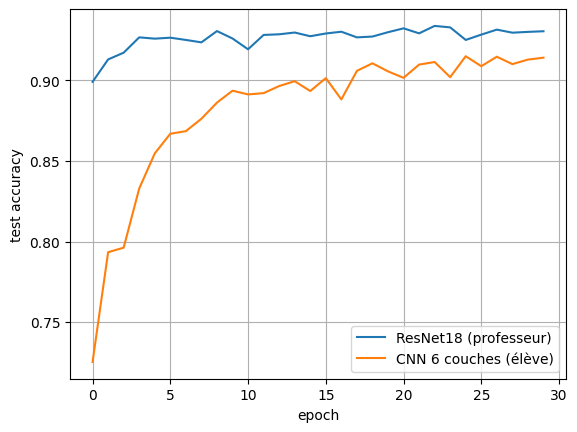


Accuracy finale professeur : 0.9305
Accuracy finale élève     : 0.9141
Écart                     : 0.01639999999999997


In [3]:
# Correction — Partie 2 : entraînement d’un professeur (ResNet18) et d’un élève (CNN 6 couches)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda")
print("Device:", device)

# Dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

# Élève : CNN à 6 couches convolutives
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.ReLU(),
            nn.Conv2d(16,16,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.classifier = nn.Linear(64,10)

    def forward(self,x):
        x = self.features(x)
        x = x.view(x.size(0),-1)
        return self.classifier(x)

# Professeur : ResNet18 adapté aux images 28x28
def build_resnet18():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(1,64,3,stride=1,padding=1,bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features,10)
    return model

teacher = build_resnet18().to(device)
student = SmallCNN().to(device)

# Compte des paramètres
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Paramètres professeur :", count_params(teacher))
print("Paramètres élève      :", count_params(student))

# Évaluation
def evaluate(model):
    model.eval()
    correct,total = 0,0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device),y.to(device)
            logits = model(x)
            pred = logits.argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)
    return correct/total

# Entraînement
def train(model, epochs=30, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(),lr=lr)
    acc_hist = []

    for e in range(epochs):
        model.train()
        for x,y in train_loader:
            x,y = x.to(device),y.to(device)

            opt.zero_grad()
            logits = model(x)
            loss = criterion(logits,y)
            loss.backward()
            opt.step()

        acc = evaluate(model)
        acc_hist.append(acc)
        print(f"epoch {e+1}/{epochs}  test_acc={acc:.3f}")

    return acc_hist

print("\n--- Entraînement professeur ---")
teacher_hist = train(teacher)

print("\n--- Entraînement élève ---")
student_hist = train(student)

# Courbes
plt.plot(teacher_hist,label="ResNet18 (professeur)")
plt.plot(student_hist,label="CNN 6 couches (élève)")
plt.xlabel("epoch")
plt.ylabel("test accuracy")
plt.legend()
plt.grid()
plt.show()

print("\nAccuracy finale professeur :", teacher_hist[-1])
print("Accuracy finale élève     :", student_hist[-1])
print("Écart                     :", teacher_hist[-1]-student_hist[-1])

# Partie 3 — Distillation

On entraîne maintenant **le même CNN élève**, mais en utilisant l’information produite par le professeur.

La méthode de distillation est **libre**.  
Vous pouvez choisir par exemple :

- régression sur les probabilités du professeur
- entropie croisée entre les distributions professeur / élève
- combinaison avec la loss standard.

Précisez votre (ou vos) choix, la manière dont vous l'implémentez et comparez ensuite :

- CNN entraîné normalement
- CNN entraîné par distillation.


### A noter :

Plusieurs situations peuvent apparaître :

1. **Le CNN simple obtient déjà des performances proches du ResNet18.**  
   Dans ce cas, la distillation peut ne pas améliorer significativement les résultats.

2. **Le CNN simple apprend difficilement.**  
   Dans ce cas, il peut être nécessaire d’ajuster :
   - la profondeur du réseau
   - le learning rate
   - le nombre d’epochs.

Si ces situations apparaissent, **il faut simplement le signaler et l’analyser**.  
L’objectif de l’exercice est d’étudier le comportement de la distillation, pas d’obtenir un résultat parfait.

Device: cuda
Paramètres élève standard  : 4726
Paramètres élève distillé  : 4726

--- Entraînement supervisé : élève CNN standard ---
epoch 01/30 | test_acc=0.6353
epoch 02/30 | test_acc=0.7144
epoch 03/30 | test_acc=0.7302
epoch 04/30 | test_acc=0.7582
epoch 05/30 | test_acc=0.7762
epoch 06/30 | test_acc=0.7792
epoch 07/30 | test_acc=0.7933
epoch 08/30 | test_acc=0.7873
epoch 09/30 | test_acc=0.8057
epoch 10/30 | test_acc=0.8094
epoch 11/30 | test_acc=0.7994
epoch 12/30 | test_acc=0.8197
epoch 13/30 | test_acc=0.8210
epoch 14/30 | test_acc=0.8284
epoch 15/30 | test_acc=0.8352
epoch 16/30 | test_acc=0.8302
epoch 17/30 | test_acc=0.8385
epoch 18/30 | test_acc=0.8395
epoch 19/30 | test_acc=0.8420
epoch 20/30 | test_acc=0.8473
epoch 21/30 | test_acc=0.8478
epoch 22/30 | test_acc=0.8354
epoch 23/30 | test_acc=0.8539
epoch 24/30 | test_acc=0.8524
epoch 25/30 | test_acc=0.8457
epoch 26/30 | test_acc=0.8422
epoch 27/30 | test_acc=0.8576
epoch 28/30 | test_acc=0.8575
epoch 29/30 | test_acc=0.8

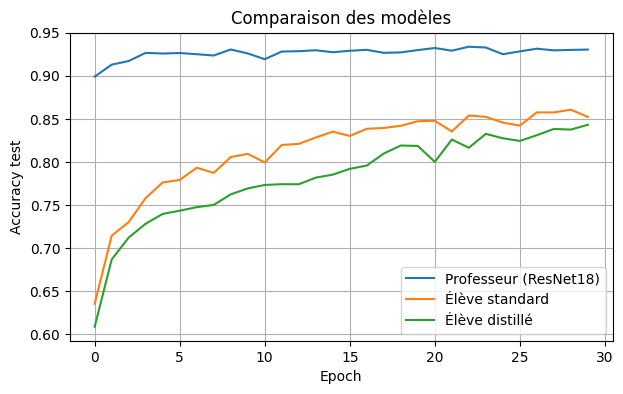


--- Résultats finaux ---
Professeur (ResNet18) : 0.9305
Élève standard        : 0.8523
Élève distillé        : 0.8432
Gain distillation vs élève standard : -0.0091


In [7]:
# Correction — Partie 3 : comparaison élève standard / élève distillé
# Ici :
# 1) on recharge Fashion-MNIST
# 2) on définit le même élève que précédemment
# 3) on entraîne l'élève standard
# 4) on prépare aussi l'élève distillé, mais son entraînement est commenté
#    car on suppose qu'il a déjà été fait auparavant

K = 4
T = 3.0
alpha = 0.7

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --------------------------------------------------
# Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --------------------------------------------------
# Dataset
# --------------------------------------------------
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

# --------------------------------------------------
# Modèle élève
# --------------------------------------------------
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, K, 3, padding=1), nn.ReLU(),
            nn.Conv2d(K, K, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(K, 2*K, 3, padding=1), nn.ReLU(),
            nn.Conv2d(2*K, 2*K, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(2*K, 4*K, 3, padding=1), nn.ReLU(),
            nn.Conv2d(4*K, 4*K, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(4*K, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

student_standard = SmallCNN().to(device)
student_distilled = SmallCNN().to(device)

# --------------------------------------------------
# Outils
# --------------------------------------------------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def train_supervised(model, train_loader, test_loader, epochs=30, lr=1e-3, name="élève standard"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    print(f"\n--- Entraînement supervisé : {name} ---")
    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        acc = evaluate(model, test_loader)
        history.append(acc)
        print(f"epoch {epoch+1:02d}/{epochs} | test_acc={acc:.4f}")

    return history

def train_distillation(student, teacher, train_loader, test_loader, epochs=30, lr=1e-3,
                       T=3.0, alpha=0.7, name="élève distillé"):
    ce = nn.CrossEntropyLoss()
    kl = nn.KLDivLoss(reduction="batchmean")
    optimizer = optim.Adam(student.parameters(), lr=lr)
    history = []

    teacher.eval()
    print(f"\n--- Entraînement par distillation : {name} ---")
    for epoch in range(epochs):
        student.train()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            with torch.no_grad():
                teacher_logits = teacher(x)

            student_logits = student(x)

            loss_hard = ce(student_logits, y)
            loss_soft = kl(
                torch.log_softmax(student_logits / T, dim=1),
                torch.softmax(teacher_logits / T, dim=1)
            ) * (T * T)

            loss = alpha * loss_soft + (1 - alpha) * loss_hard

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        acc = evaluate(student, test_loader)
        history.append(acc)
        print(f"epoch {epoch+1:02d}/{epochs} | test_acc={acc:.4f}")

    return history

# --------------------------------------------------
# Infos modèles
# --------------------------------------------------
print("Paramètres élève standard  :", count_params(student_standard))
print("Paramètres élève distillé  :", count_params(student_distilled))

# --------------------------------------------------
# Entraînement de l'élève standard
# --------------------------------------------------
student_standard_hist = train_supervised(
    student_standard, train_loader, test_loader,
    epochs=30, lr=1e-3, name="élève CNN standard"
)

--------------------------------------------------
Entraînement de l'élève distillé
--------------------------------------------------
Décommenter seulement si student_distilled_hist n'existe pas déjà

student_distilled_hist = train_distillation(
    student_distilled, teacher, train_loader, test_loader,
    epochs=30, lr=1e-3, T=T, alpha=alpha, name="élève CNN distillé"
)

# --------------------------------------------------
# Comparaison finale
# --------------------------------------------------
plt.figure(figsize=(7,4))

if "teacher_hist" in globals():
    plt.plot(teacher_hist, label="Professeur (ResNet18)")

plt.plot(student_standard_hist, label="Élève standard")

if "student_distilled_hist" in globals():
    plt.plot(student_distilled_hist, label="Élève distillé")

plt.xlabel("Epoch")
plt.ylabel("Accuracy test")
plt.title("Comparaison des modèles")
plt.grid()
plt.legend()
plt.show()

print("\n--- Résultats finaux ---")
if "teacher_hist" in globals():
    print(f"Professeur (ResNet18) : {teacher_hist[-1]:.4f}")
print(f"Élève standard        : {student_standard_hist[-1]:.4f}")
if "student_distilled_hist" in globals():
    print(f"Élève distillé        : {student_distilled_hist[-1]:.4f}")
    print(f"Gain distillation vs élève standard : {student_distilled_hist[-1] - student_standard_hist[-1]:.4f}")


--- alpha=0, T=5 | alpha=0.0, T=5.0 ---
epoch 01/30 | test_acc=0.6601
epoch 02/30 | test_acc=0.7000
epoch 03/30 | test_acc=0.6935
epoch 04/30 | test_acc=0.7414
epoch 05/30 | test_acc=0.7543
epoch 06/30 | test_acc=0.7575
epoch 07/30 | test_acc=0.7748
epoch 08/30 | test_acc=0.7892
epoch 09/30 | test_acc=0.7918
epoch 10/30 | test_acc=0.7921
epoch 11/30 | test_acc=0.8072
epoch 12/30 | test_acc=0.8154
epoch 13/30 | test_acc=0.8051
epoch 14/30 | test_acc=0.8210
epoch 15/30 | test_acc=0.8145
epoch 16/30 | test_acc=0.8171
epoch 17/30 | test_acc=0.8217
epoch 18/30 | test_acc=0.8327
epoch 19/30 | test_acc=0.8311
epoch 20/30 | test_acc=0.8443
epoch 21/30 | test_acc=0.8282
epoch 22/30 | test_acc=0.8465
epoch 23/30 | test_acc=0.8493
epoch 24/30 | test_acc=0.8504
epoch 25/30 | test_acc=0.8535
epoch 26/30 | test_acc=0.8522
epoch 27/30 | test_acc=0.8602
epoch 28/30 | test_acc=0.8590
epoch 29/30 | test_acc=0.8583
epoch 30/30 | test_acc=0.8632

--- alpha=1, T=5 | alpha=1.0, T=5.0 ---
epoch 01/30 | test

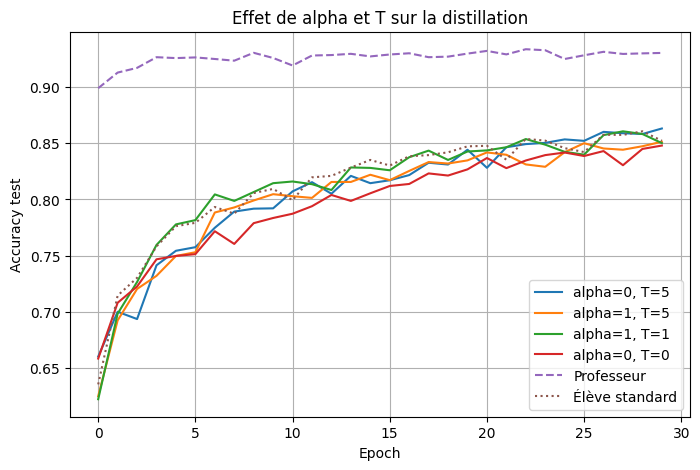


--- Résultats finaux ---
alpha=0, T=5        : 0.8632
alpha=1, T=5        : 0.8514
alpha=1, T=1        : 0.8502
alpha=0, T=0        : 0.8480


In [8]:
# Tests de plusieurs couples (alpha, T) sans redéfinir SmallCNN ni K
# Hypothèses :
# - SmallCNN est déjà défini
# - teacher est déjà entraîné
# - train_loader, test_loader, device existent déjà

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def train_distillation(student, teacher, train_loader, test_loader, epochs=30, lr=1e-3,
                       T=3.0, alpha=0.7, name="élève"):
    ce = nn.CrossEntropyLoss()
    kl = nn.KLDivLoss(reduction="batchmean")
    optimizer = optim.Adam(student.parameters(), lr=lr)
    history = []

    teacher.eval()
    print(f"\n--- {name} | alpha={alpha}, T={T} ---")

    for epoch in range(epochs):
        student.train()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            student_logits = student(x)
            loss_hard = ce(student_logits, y)

            # Cas alpha = 0 : pas de distillation, donc on n'utilise pas T
            if alpha == 0:
                loss = loss_hard
            else:
                if T <= 0:
                    raise ValueError(f"T doit être strictement positif si alpha > 0. Ici T={T}.")
                with torch.no_grad():
                    teacher_logits = teacher(x)

                loss_soft = kl(
                    torch.log_softmax(student_logits / T, dim=1),
                    torch.softmax(teacher_logits / T, dim=1)
                ) * (T * T)

                loss = alpha * loss_soft + (1 - alpha) * loss_hard

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        acc = evaluate(student, test_loader)
        history.append(acc)
        print(f"epoch {epoch+1:02d}/{epochs} | test_acc={acc:.4f}")

    return history

# Configurations demandées
configs = [
    {"alpha": 0.0, "T": 5.0, "label": "alpha=0, T=5"},
    {"alpha": 1.0, "T": 5.0, "label": "alpha=1, T=5"},
    {"alpha": 1.0, "T": 1.0, "label": "alpha=1, T=1"},
    {"alpha": 0.0, "T": 1.0, "label": "alpha=0, T=0"},
]

results = {}

for cfg in configs:
    student = SmallCNN().to(device)
    hist = train_distillation(
        student, teacher,
        train_loader, test_loader,
        epochs=30, lr=1e-3,
        T=cfg["T"], alpha=cfg["alpha"],
        name=cfg["label"]
    )
    results[cfg["label"]] = hist

# Affichage des courbes
plt.figure(figsize=(8, 5))
for label, hist in results.items():
    plt.plot(hist, label=label)

# Si elles existent déjà dans ton notebook, on les ajoute
if "teacher_hist" in globals():
    plt.plot(teacher_hist, label="Professeur", linestyle="--")
if "student_standard_hist" in globals():
    plt.plot(student_standard_hist, label="Élève standard", linestyle=":")

plt.xlabel("Epoch")
plt.ylabel("Accuracy test")
plt.title("Effet de alpha et T sur la distillation")
plt.grid()
plt.legend()
plt.show()

print("\n--- Résultats finaux ---")
for label, hist in results.items():
    print(f"{label:20s}: {hist[-1]:.4f}")


Standard student runs

Mild distillation runs

Strong distillation runs


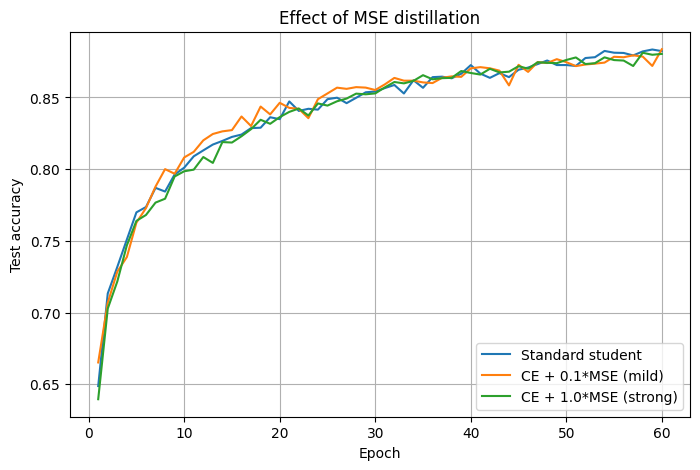


Final mean accuracies
Standard : 0.8822666666666666
Mild     : 0.8836
Strong   : 0.8803333333333333


In [9]:
# Experiments : CrossEntropy + MSE distillation
# 5 runs each, 60 epochs

EPOCHS = 60
N_RUNS = 3
LR = 1e-3

# Distillation strengths
mild_lambda = 0.1
strong_lambda = 1.0

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

ce = nn.CrossEntropyLoss()
mse = nn.MSELoss()

def evaluate(model, loader):
    model.eval()
    correct,total = 0,0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device),y.to(device)
            logits = model(x)
            pred = logits.argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)
    return correct/total


def train_student(model, train_loader, test_loader, epochs=60, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()

        for x,y in train_loader:
            x,y = x.to(device),y.to(device)

            logits = model(x)
            loss = ce(logits,y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        history.append(evaluate(model,test_loader))

    return history


def train_distilled(model, teacher, train_loader, test_loader, lamb=0.1, epochs=60, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    teacher.eval()

    for epoch in range(epochs):
        model.train()

        for x,y in train_loader:
            x,y = x.to(device),y.to(device)

            with torch.no_grad():
                teacher_probs = torch.softmax(teacher(x),dim=1)

            student_logits = model(x)
            student_probs = torch.softmax(student_logits,dim=1)

            loss_ce = ce(student_logits,y)
            loss_mse = mse(student_probs,teacher_probs)

            loss = loss_ce + lamb*loss_mse

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        history.append(evaluate(model,test_loader))

    return history


# --------------------------------------------------
# Experiments
# --------------------------------------------------

standard_runs = []
mild_runs = []
strong_runs = []

print("\nStandard student runs")
for i in range(N_RUNS):
    model = SmallCNN().to(device)
    hist = train_student(model,train_loader,test_loader,EPOCHS,LR)
    standard_runs.append(hist)

print("\nMild distillation runs")
for i in range(N_RUNS):
    model = SmallCNN().to(device)
    hist = train_distilled(model,teacher,train_loader,test_loader,
                           lamb=mild_lambda,epochs=EPOCHS,lr=LR)
    mild_runs.append(hist)

print("\nStrong distillation runs")
for i in range(N_RUNS):
    model = SmallCNN().to(device)
    hist = train_distilled(model,teacher,train_loader,test_loader,
                           lamb=strong_lambda,epochs=EPOCHS,lr=LR)
    strong_runs.append(hist)


standard_runs = np.array(standard_runs)
mild_runs = np.array(mild_runs)
strong_runs = np.array(strong_runs)

standard_mean = standard_runs.mean(0)
mild_mean = mild_runs.mean(0)
strong_mean = strong_runs.mean(0)

# --------------------------------------------------
# Plot
# --------------------------------------------------

epochs = np.arange(1,EPOCHS+1)

plt.figure(figsize=(8,5))

plt.plot(epochs,standard_mean,label="Standard student")
plt.plot(epochs,mild_mean,label="CE + 0.1*MSE (mild)")
plt.plot(epochs,strong_mean,label="CE + 1.0*MSE (strong)")

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Effect of MSE distillation")
plt.grid()
plt.legend()
plt.show()

print("\nFinal mean accuracies")
print("Standard :",standard_mean[-1])
print("Mild     :",mild_mean[-1])
print("Strong   :",strong_mean[-1])

# Conclusion

Comparer les trois modèles :

- professeur (ResNet18)
- élève standard
- élève distillé.

Discuter :

- les différences de performances
- ce que le professeur transmet à l’élève
- dans quelles conditions la distillation peut améliorer un modèle de capacité fixe.